<a href="https://colab.research.google.com/github/sumitnain2023-rgb/customer_churn_predication/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score,precision_score,f1_score,recall_score,roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

### Data Loading and Initial Inspection

Loads the Telco Customer Churn dataset into a pandas DataFrame and displays the first few rows to get an overview of the data.

### Library Imports

This section imports all necessary libraries for data manipulation, machine learning modeling, and visualization.

In [56]:
df = pd.read_csv(r'WA_Fn-UseC_-Telco-Customer-Churn.csv',nrows=50000)
# Display the first 10 rows of the DataFrame to get an initial overview of the data structure and content.
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### Target Variable Distribution

Checks the distribution of the 'Churn' target variable to understand class balance before preprocessing.

In [57]:
# Check the distribution of the 'Churn' target variable.
# This helps in understanding the class balance or imbalance in the dataset,
# which is crucial for model evaluation and choosing appropriate resampling techniques like SMOTE.
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [58]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # Convert 'TotalCharges' to numeric, coercing errors to NaN.
df.dropna(subset=['TotalCharges'], inplace=True) # Drop rows where 'TotalCharges' is NaN.

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}) # Map 'Yes' to 1 and 'No' to 0 for the 'Churn' target variable.
df.dropna(subset=['Churn'], inplace=True) # Drop rows where 'Churn' is NaN.

if "customerID" in df.columns:
  df = df.drop(columns=['customerID']) # Drop 'customerID' column as it's a unique identifier and not useful for modeling.

y = df['Churn'] # Assign the 'Churn' column as the target variable (y).
X = df.drop(columns=['Churn']) # Assign all other columns as features (X).

X = pd.get_dummies(X, drop_first=True) # Convert categorical features into one-hot encoded numerical features.
# 'drop_first=True' prevents multicollinearity by dropping the first category in each one-hot encoded feature.

### Logistic Regression Model Training and Prediction

This section initializes, trains, and makes predictions using the Logistic Regression model, followed by printing its classification report, confusion matrix, and ROC AUC score.

### Data Splitting, Resampling, and Scaling

This section prepares the data for model training by splitting it into training and testing sets, handling class imbalance using SMOTE, and scaling numerical features.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Addressing class imbalance using SMOTE.
# SMOTE creates synthetic samples of the minority class (Churn=Yes) to balance the dataset,
# preventing the model from being biased towards the majority class (No Churn).
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scaling numerical features using StandardScaler.
# Standardization is crucial for many machine learning algorithms (like Logistic Regression, SVMs)
# as it transforms features to have a mean of 0 and a standard deviation of 1.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
) # Split data into training (70%) and testing (30%) sets.
# 'random_state=42' ensures reproducibility of the split.
# 'stratify=y' ensures that the proportion of target classes is the same in both training and testing sets.

smote = SMOTE(random_state=42) # Initialize SMOTE for oversampling the minority class.
# 'random_state=42' ensures reproducibility of SMOTE's synthetic sample generation.
X_train_res, y_train_res = smote.fit_resample(X_train, y_train) # Apply SMOTE to the training data to handle class imbalance.

scaler = StandardScaler() # Initialize StandardScaler for feature scaling.
X_train_scaled = scaler.fit_transform(X_train_res) # Fit and transform the training features.
X_test_scaled = scaler.transform(X_test) # Transform the test features using the scaler fitted on training data.

### Logistic Regression Model

In [60]:
log_reg = LogisticRegression(random_state=42) # Initialize Logistic Regression model.
# 'random_state=42' ensures reproducibility of the model's stochastic processes.
log_reg.fit(X_train_scaled, y_train_res) # Train the model on the scaled and resampled training data.

y_pred_log_reg = log_reg.predict(X_test_scaled) # Make predictions on the scaled test data.
y_prob_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1] # Get probabilities for the positive class (Churn=1).

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg)) # Print classification report for detailed performance metrics.

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg)) # Print confusion matrix to understand true positives/negatives and false positives/negatives.

print("Logistic Regression ROC AUC Score:", roc_auc_score(y_test, y_prob_log_reg)) # Print ROC AUC score for overall model performance.

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1549
           1       0.57      0.64      0.60       561

    accuracy                           0.77      2110
   macro avg       0.71      0.73      0.72      2110
weighted avg       0.78      0.77      0.78      2110

Logistic Regression Confusion Matrix:
[[1273  276]
 [ 202  359]]
Logistic Regression ROC AUC Score: 0.81652759701216


### Decision Tree Model Training and Prediction

Initializes, trains, and makes predictions using a Decision Tree classifier, followed by printing its classification report, confusion matrix, and ROC AUC score.

### Evaluation Visualization for Logistic Regression

/tmp/ipykernel_12010/527193542.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')


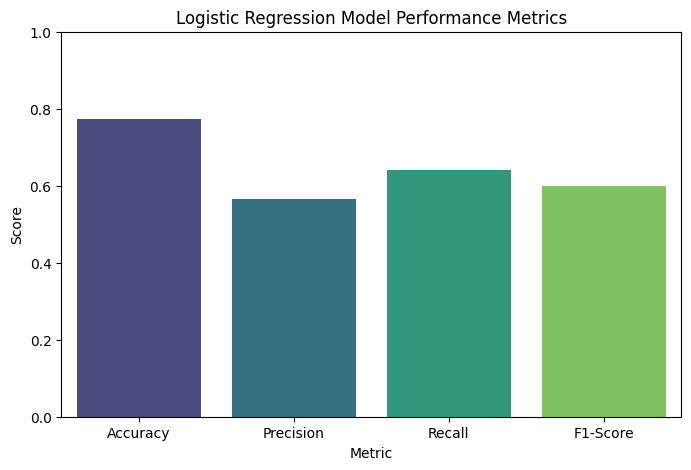

In [63]:
accuracy = accuracy_score(y_test, y_pred_log_reg)
precision = precision_score(y_test, y_pred_log_reg)
recall = recall_score(y_test, y_pred_log_reg)
f1 = f1_score(y_test, y_pred_log_reg)

# Collect the calculated metrics into a DataFrame for easy plotting.
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
}
metrics_df = pd.DataFrame(metrics_data)

# Create a bar plot to visualize the performance metrics.
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')
plt.title('Logistic Regression Model Performance Metrics') # Set the title of the plot.
plt.ylim(0, 1) # Ensure the Y-axis ranges from 0 to 1, as these are score metrics.
plt.ylabel('Score') # Label for the Y-axis.
plt.show()

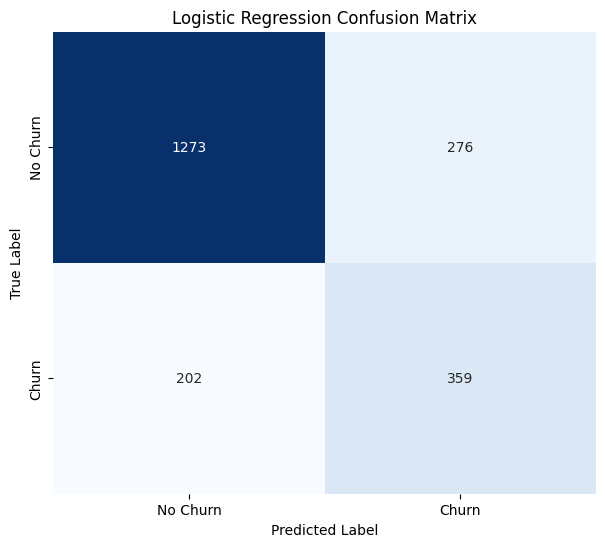

In [64]:
cm = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(7, 6))
# Create a heatmap for the confusion matrix for better visual representation.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn']) # 'annot=True' displays values, 'fmt='d'' formats as integers.
plt.xlabel('Predicted Label') # Label for the X-axis (predicted classes).
plt.ylabel('True Label') # Label for the Y-axis (actual classes).
plt.title('Logistic Regression Confusion Matrix') # Set the title of the plot.
plt.show()

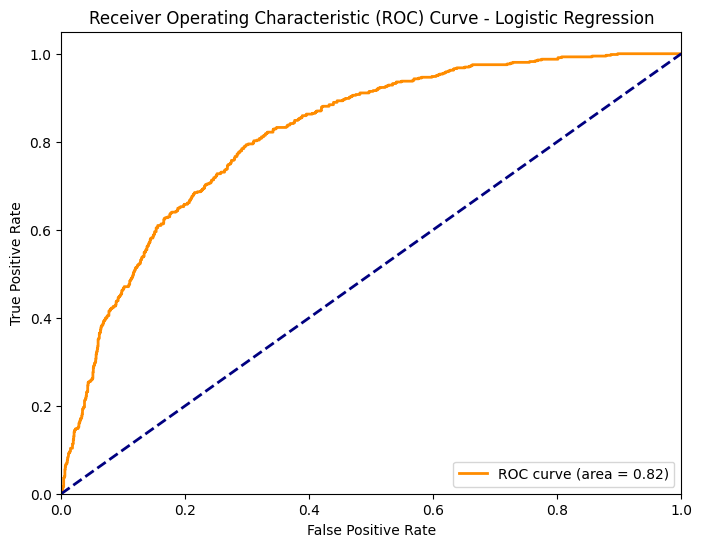

In [65]:
# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log_reg)
roc_auc = roc_auc_score(y_test, y_prob_log_reg) # Calculate the Area Under the Receiver Operating Characteristic Curve (ROC AUC).

plt.figure(figsize=(8, 6))
# Plot the ROC curve.
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
# Plot the random guess line (diagonal).
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]) # Set X-axis limits from 0 to 1.
plt.ylim([0.0, 1.05]) # Set Y-axis limits from 0 to 1.05 to give some buffer.
plt.xlabel('False Positive Rate') # Label for the X-axis.
plt.ylabel('True Positive Rate') # Label for the Y-axis.
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression') # Set the title of the plot.
plt.legend(loc='lower right') # Display the legend in the lower right corner.
plt.show()

In [61]:
### Decision Tree Model

# Initialize and train the Decision Tree model
dtree = DecisionTreeClassifier(random_state=42) # Initialize Decision Tree Classifier.
# 'random_state=42' ensures reproducibility of the tree building process.
dtree.fit(X_train_scaled, y_train_res) # Train the model on the scaled and resampled training data.

# Make predictions
y_pred_dtree = dtree.predict(X_test_scaled) # Make predictions on the scaled test data.
y_prob_dtree = dtree.predict_proba(X_test_scaled)[:, 1] # Get probabilities for the positive class (Churn=1).

### XGBoost Model Training and Prediction

Initializes, trains, and makes predictions using an XGBoost classifier, followed by printing its classification report, confusion matrix, and ROC AUC score.

### Decision Tree Evaluation

In [46]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dtree))#creating classification report

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dtree))#creating confsion matrix

print("Decision Tree ROC AUC Score:", roc_auc_score(y_test, y_prob_dtree))#creating roc score

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1549
           1       0.48      0.54      0.51       561

    accuracy                           0.72      2110
   macro avg       0.65      0.67      0.66      2110
weighted avg       0.73      0.72      0.73      2110

Decision Tree Confusion Matrix:
[[1222  327]
 [ 257  304]]
Decision Tree ROC AUC Score: 0.665948590833716


### Evaluation Visualization for Decision Tree

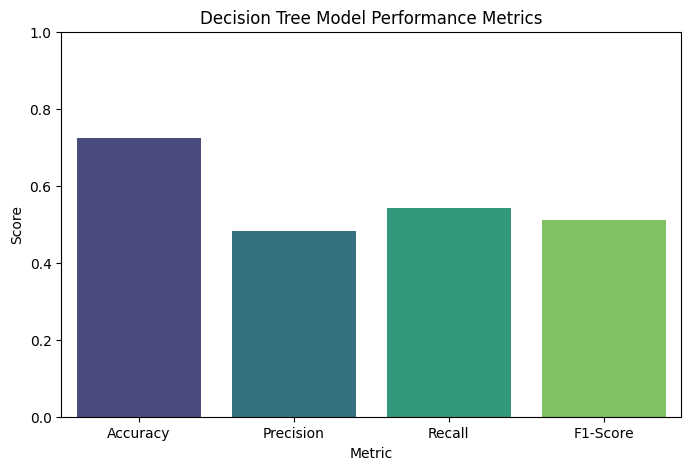

In [66]:
# Calculate metrics for visualization for the Decision Tree model.
accuracy_dtree = accuracy_score(y_test, y_pred_dtree)
precision_dtree = precision_score(y_test, y_pred_dtree)
recall_dtree = recall_score(y_test, y_pred_dtree)
f1_dtree = f1_score(y_test, y_pred_dtree)

# Create a DataFrame for metrics for easy plotting.
metrics_data_dtree = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy_dtree, precision_dtree, recall_dtree, f1_dtree]
}
metrics_df_dtree = pd.DataFrame(metrics_data_dtree)

# Plotting performance metrics (Bar Plot).
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Metric', data=metrics_df_dtree, palette='viridis', legend=False) # 'hue' and 'legend=False' for distinct bar colors.
plt.title('Decision Tree Model Performance Metrics') # Set the title of the plot.
plt.ylim(0, 1) # Ensure the Y-axis ranges from 0 to 1.
plt.ylabel('Score') # Label for the Y-axis.
plt.show()

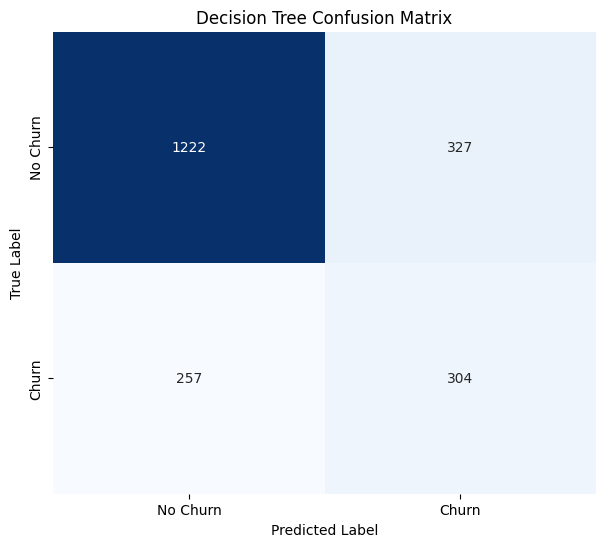

In [67]:
# Plotting Confusion Matrix for Decision Tree (Heatmap).
cm_dtree = confusion_matrix(y_test, y_pred_dtree)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_dtree, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn']) # Customize labels and remove color bar.
plt.xlabel('Predicted Label') # Label for the X-axis.
plt.ylabel('True Label') # Label for the Y-axis.
plt.title('Decision Tree Confusion Matrix') # Set the title of the plot.
plt.show()

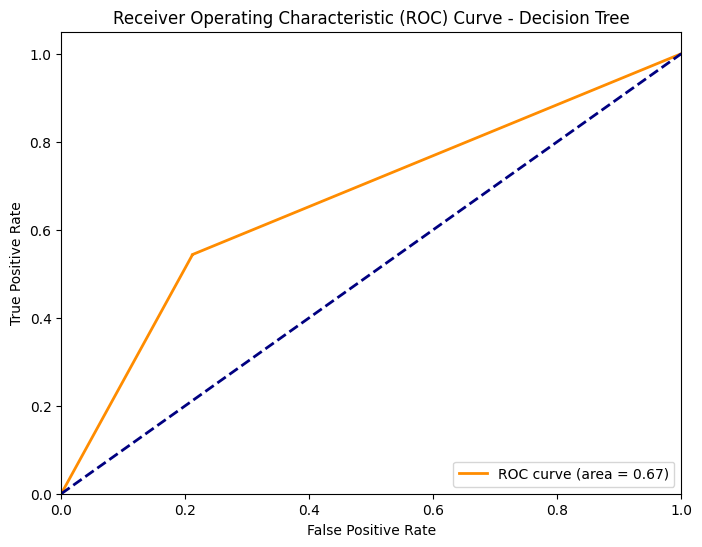

In [68]:
# Plotting ROC Curve for Decision Tree (Line Chart).
fpr_dtree, tpr_dtree, thresholds_dtree = roc_curve(y_test, y_prob_dtree) # Calculate FPR, TPR, thresholds.
roc_auc_dtree = roc_auc_score(y_test, y_prob_dtree) # Calculate ROC AUC score.

plt.figure(figsize=(8, 6))
plt.plot(fpr_dtree, tpr_dtree, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dtree:.2f})') # Plot the ROC curve.
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Plot the diagonal random guess line.
plt.xlim([0.0, 1.0]) # Set X-axis limits.
plt.ylim([0.0, 1.05]) # Set Y-axis limits.
plt.xlabel('False Positive Rate') # Label for the X-axis.
plt.ylabel('True Positive Rate') # Label for the Y-axis.
plt.title('Receiver Operating Characteristic (ROC) Curve - Decision Tree') # Set the title of the plot.
plt.legend(loc='lower right') # Display legend.
plt.show()

### XGBoost Model

In [62]:
# Initialize and train the XGBoost model
xgb = XGBClassifier(random_state=42, eval_metric='logloss') # Initialize XGBoost Classifier.
# 'random_state=42' ensures reproducibility of the model.
# 'eval_metric='logloss'' specifies the evaluation metric used for early stopping if validation sets are provided.
xgb.fit(X_train_scaled, y_train_res) # Train the model on the scaled and resampled training data.

# Make predictions
y_pred_xgb = xgb.predict(X_test_scaled) # Make predictions on the scaled test data.
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1] # Get probabilities for the positive class (Churn=1).

### XGBoost Evaluation

In [51]:
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("XGBoost ROC AUC Score:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1549
           1       0.56      0.57      0.57       561

    accuracy                           0.77      2110
   macro avg       0.70      0.70      0.70      2110
weighted avg       0.77      0.77      0.77      2110

XGBoost Confusion Matrix:
[[1303  246]
 [ 242  319]]
XGBoost ROC AUC Score: 0.8019779306757623


### Evaluation Visualization for XGBoost

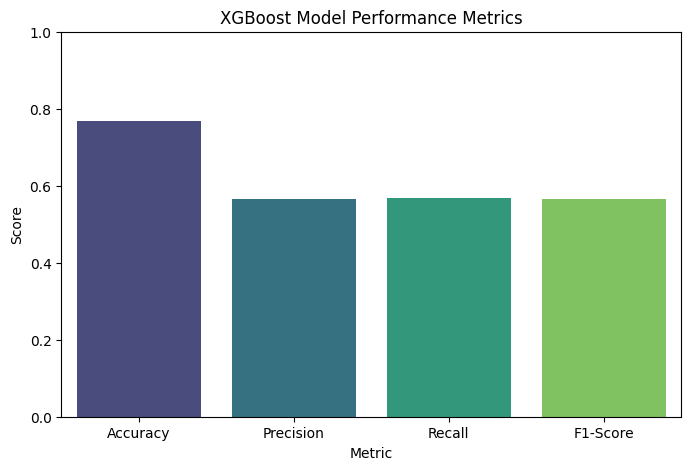

In [69]:
# Calculate metrics for visualization for the XGBoost model.
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Create a DataFrame for metrics for easy plotting.
metrics_data_xgb = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy_xgb, precision_xgb, recall_xgb, f1_xgb]
}
metrics_df_xgb = pd.DataFrame(metrics_data_xgb)

# Plotting performance metrics (Bar Plot).
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Metric', data=metrics_df_xgb, palette='viridis', legend=False) # Use 'hue' for colored bars.
plt.title('XGBoost Model Performance Metrics') # Set the title.
plt.ylim(0, 1) # Set Y-axis limits.
plt.ylabel('Score') # Label for the Y-axis.
plt.show()

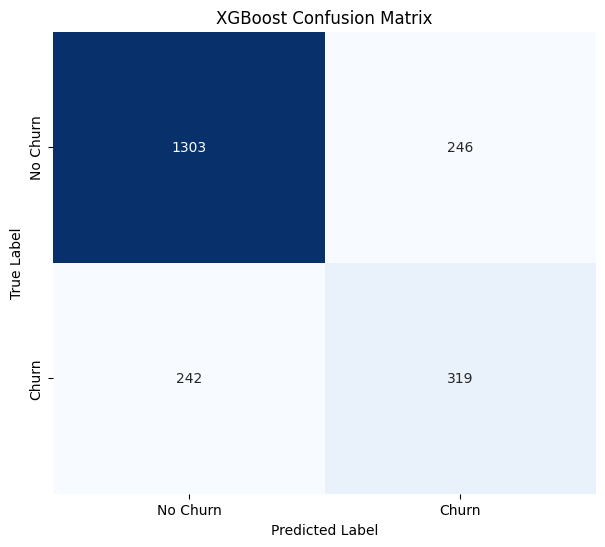

In [70]:
# Plotting Confusion Matrix for XGBoost (Heatmap).
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn']) # 'annot=True' to show numbers in cells.
plt.xlabel('Predicted Label') # Label for the X-axis.
plt.ylabel('True Label') # Label for the Y-axis.
plt.title('XGBoost Confusion Matrix') # Set the title.
plt.show()

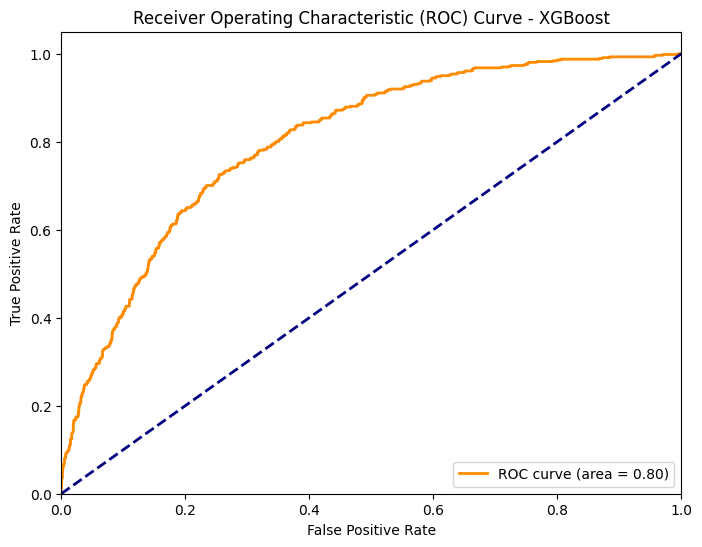

In [71]:
# Plotting ROC Curve for XGBoost (Line Chart).
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb) # Calculate FPR, TPR, thresholds.
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb) # Calculate ROC AUC score.

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_xgb:.2f})') # Plot the ROC curve.
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Plot the diagonal random guess line.
plt.xlim([0.0, 1.0]) # Set X-axis limits.
plt.ylim([0.0, 1.05]) # Set Y-axis limits.
plt.xlabel('False Positive Rate') # Label for the X-axis.
plt.ylabel('True Positive Rate') # Label for the Y-axis.
plt.title('Receiver Operating Characteristic (ROC) Curve - XGBoost') # Set the title.
plt.legend(loc='lower right') # Display legend.
plt.show()